In [1]:
# for PPOclip for continuous action space

from tqdm import tqdm
import numpy as np
import random
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt



In [10]:
# different from discrete action
class PolicyNet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc_mu = nn.Linear(hidden_dim, action_dim)
        self.fc_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        mu = 2.0 * torch.tanh(self.fc_mu(x))  # Gaussian mean
        std = F.softplus(self.fc_std(x)) # Gaussian standard deviation
        return mu, std

In [82]:
# different from discrete action
class PolicyNet_simple(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet_simple, self).__init__()
        self.log_std = nn.Parameter(torch.randn(action_dim))
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc_mu = nn.Linear(hidden_dim, action_dim)
        #self.fc_std = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        mu = 2.0 * torch.tanh(self.fc_mu(x))  # Gaussian mean
        #std = F.softplus(self.fc_std(x)) # Gaussian standard deviation
        std = torch.exp(self.log_std)
        return mu, std

In [32]:
# same as discrete action
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        return self.fc2(x)

In [4]:
# different
def take_action(actor,state):
    state = torch.tensor([state], dtype=torch.float).to(device)
    mu, std = actor(state)
    action_dist = torch.distributions.Normal(mu, std)
    action = action_dist.sample()
    return [action.item()]

# same
def compute_advantage(gamma, lmbda, td_delta):
    td_delta = td_delta.detach().numpy()
    advantage_list = []
    advantage = 0.0
    for delta in td_delta[::-1]:
        advantage = gamma * lmbda * advantage + delta
        advantage_list.append(advantage)
    advantage_list.reverse()
    return torch.tensor(advantage_list, dtype=torch.float)

# same
def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

In [59]:
return_lists = []

In [96]:
actor_lr = 1e-4      # 1e-3
critic_lr = 5e-3     #1e-2  
num_episodes = 2500
hidden_dim = 128
gamma = 0.96         #0.98
lmbda = 0.92         #0.95
epochs = 10
epsilon = 0.2

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
#env_name = 'CartPole-v0'
env_name = 'Pendulum-v0'
env = gym.make(env_name)
env.seed(10)
torch.manual_seed(10)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]   # for continuous action space

In [97]:
actor = PolicyNet_simple(state_dim, hidden_dim, action_dim).to(device)
critic = ValueNet(state_dim, hidden_dim).to(device)
actor_optimizer = torch.optim.Adam(actor.parameters(),lr=actor_lr)
critic_optimizer = torch.optim.Adam(critic.parameters(), lr=critic_lr)
return_list = []
for i in range(10):
    with tqdm(total=int(num_episodes/10), desc='Group %d' % i) as pbar:
        for i_episode in range(int(num_episodes/10)):
            # collect transitions for one episode under current actor (policy)
            episode_return = 0
            trans_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
            state = env.reset()
            done = False
            while not done:
                action = take_action(actor,state)
                next_state, reward, done, _ = env.step(action)
                trans_dict['states'].append(state)
                trans_dict['actions'].append(action)
                trans_dict['next_states'].append(next_state)
                trans_dict['rewards'].append(reward)
                trans_dict['dones'].append(done)
                state = next_state
                episode_return += reward
            return_list.append(episode_return)
            
            states = torch.tensor(trans_dict['states'], dtype=torch.float).to(device)
            actions = torch.tensor(trans_dict['actions']).view(-1, 1).to(device)
            rewards = torch.tensor(trans_dict['rewards'], dtype=torch.float).view(-1, 1).to(device)
            #rewards = (rewards+8.0) / 8.0    # adjust rewards 
            next_states = torch.tensor(trans_dict['next_states'],dtype=torch.float).to(device)
            dones = torch.tensor(trans_dict['dones'],dtype=torch.float).view(-1, 1).to(device)

            # Estimate TD target
            td_target = rewards +  gamma *  critic(next_states) * (1 - dones)
            
            # Estimate advantage
            td_error = td_target -  critic(states)  # TD error
            advantage = compute_advantage(gamma, lmbda, td_error.cpu()).to( device)
            
            mu, std = actor(states)
            action_dists = torch.distributions.Normal(mu.detach(), std.detach())
        
            old_log_probs = action_dists.log_prob(actions)
            # .detach(): no gradient calculation for old actor
        
            # Update actor and critic
            for _ in range( epochs):
                mu, std = actor(states)
                action_dists = torch.distributions.Normal(mu, std)
                log_probs = action_dists.log_prob(actions)
                #log_probs = torch.log( actor(states).gather(1, actions))
                ratio = torch.exp(log_probs - old_log_probs)
            
                #surr1 = ratio * advantage
                #surr2 = torch.clamp(ratio, 1- epsilon, 1+ epsilon)*advantage
                #actor_loss = torch.mean(-torch.min(surr1, surr2))
                surr1 = ratio * advantage
                surr2 = (1+torch.sign(advantage)* epsilon)*advantage
            
                actor_loss = torch.mean(-torch.min(surr1, surr2))
            
                square_error = F.mse_loss( critic(states), td_target.detach())
                # td_target: not gradient
                critic_loss = torch.mean(square_error)
                
                actor_optimizer.zero_grad()
                critic_optimizer.zero_grad()
                
                actor_loss.backward()  # calculate actor gradient
                critic_loss.backward()  # calculate critic gradient
                
                actor_optimizer.step()  # update actor
                critic_optimizer.step()  # update critic
            
            
            if (i_episode+1) % 10 == 0:
                pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
            pbar.update(1)

return_lists.append(return_list)  
# save multiple runs with different env.seed()
# make sure change the seed before running this cell each time

Group 9: 100%|████████████████████████████████████████| 250/250 [00:46<00:00,  5.33it/s, episode=2500, return=-192.050]


In [98]:
len(return_lists)

8

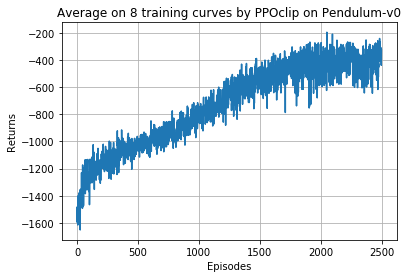

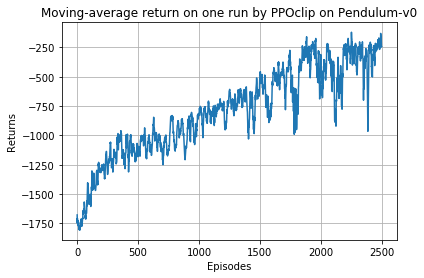

In [101]:
average_list = np.mean(return_lists, axis=0)
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, average_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Average on {} training curves by PPOclip on {}'.format(len(return_lists),env_name))
plt.grid()
plt.show()

mv_return = moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Moving-average return on one run by PPOclip on {}'.format(env_name))
plt.grid()
plt.show()


In [103]:

total_reward = 0.0
with torch.no_grad():
    for j in range (10):
        total_reward = 0.0  # for 10 consecutive episodes
        for i in range (10): 
            done = False
            observation = env.reset()
            t=0
            while not done:
                t += 1
                if i == 0:
                    env.render()
                action = take_action(actor,observation)
                observation_new, reward, done, info = env.step(action)
                observation = observation_new
                total_reward += reward
        #print("group",j, "reward", total_reward)
        print("Group", j, "average reward (per timestep) =", total_reward/(10.*200))
env.close()           



Group 0 average reward (per timestep) = -0.8917148172788438
Group 1 average reward (per timestep) = -0.7122925979953258
Group 2 average reward (per timestep) = -1.0106411915632583
Group 3 average reward (per timestep) = -1.4791934423353388
Group 4 average reward (per timestep) = -1.4457667767003806
Group 5 average reward (per timestep) = -1.3500440255469608
Group 6 average reward (per timestep) = -1.1453293011995995
Group 7 average reward (per timestep) = -0.7836504699190566
Group 8 average reward (per timestep) = -1.485382988450195
Group 9 average reward (per timestep) = -0.8197216623149715
